[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/joshtovar/MAT422/blob/main/MAT422_Section1_3_QR_LeastSquares.ipynb)

# MAT 422 - Section 1.3: QR Decomposition, Least Squares, and Linear Regression

**Topics:** QR decomposition, least-squares problems, linear regression

> Student note: This Colab badge is required for submission. Create or edit the notebook in Google Colab, then save it directly to GitHub so the badge/icon remains available for grading and reruns.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.3.1 QR Decomposition

QR decomposition factors a matrix A into A = QR. The columns of Q are orthonormal, so the dot product forms the identity matrix. R is also an upper triangle matrix. Orthonomal columns will simplify calculations always.

In [2]:
# Make matrix A
A = np.array([
    [2, 1],
    [3, 5],
    [4, 2],
    [1, 6],
], dtype=float)

Q, R = np.linalg.qr(A)

print("A =")
print(A)
print("\nQ =")
print(Q)
print("\nR =")
print(R)
print("\nQ.T @ Q =")
print(Q.T @ Q)
print("\nQ @ R =")
print(Q @ R)
print("Q has orthonormal columns?", np.allclose(Q.T @ Q, np.eye(Q.shape[1])))
print("Q @ R reconstructs A?", np.allclose(Q @ R, A))

A =
[[2. 1.]
 [3. 5.]
 [4. 2.]
 [1. 6.]]

Q =
[[-0.3651  0.183 ]
 [-0.5477 -0.326 ]
 [-0.7303  0.366 ]
 [-0.1826 -0.8522]]

R =
[[-5.4772 -5.6598]
 [ 0.     -5.8281]]

Q.T @ Q =
[[ 1. -0.]
 [-0.  1.]]

Q @ R =
[[2. 1.]
 [3. 5.]
 [4. 2.]
 [1. 6.]]
Q has orthonormal columns? True
Q @ R reconstructs A? True


This shows that Q has orthonormal columns, and multiplying Q by R will reconstruct the original matrix A.

## 1.3.2 Least-Squares Problems

A least-squares problem solves an overdetermined system A x approximately equals b. There may be no exact solution, so we choose x that minimizes the residual norm ||b - A x||. QR decomposition gives a stable way to solve this problem.

In [3]:
# Make a 4 element vector
b = np.array([3, 8, 6, 10], dtype=float)

x_lstsq, residual_sum, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)
residual = b - A @ x_lstsq

print("Least-squares solution from np.linalg.lstsq:", x_lstsq)
print("residual vector b - A @ x =", residual)
print("residual norm =", np.linalg.norm(residual))
print("rank of A =", rank)
print("singular values =", singular_values)
print("normal-equation check A.T @ residual =", A.T @ residual)

Least-squares solution from np.linalg.lstsq: [0.6467 1.4387]
residual vector b - A @ x = [ 0.2679 -1.1335  0.5358  0.7213]
residual norm = 1.4710153510092292
rank of A = 2
singular values = [9.1568 3.4861]
normal-equation check A.T @ residual = [-0. -0.]


In [4]:
# Use QR factorization
y = Q.T @ b
x_qr = np.linalg.solve(R, y)
qr_residual = b - A @ x_qr

print("Q.T @ b =", y)
print("Least-squares solution from QR:", x_qr)
print("QR residual norm =", np.linalg.norm(qr_residual))
print("QR solution matches np.linalg.lstsq?", np.allclose(x_qr, x_lstsq))

Q.T @ b = [-11.6847  -8.3847]
Least-squares solution from QR: [0.6467 1.4387]
QR residual norm = 1.4710153510092308
QR solution matches np.linalg.lstsq? True


The normal-equation check (A.T @ residual) is close to 0, which means the residual is orthogonal to the column space of A. This proves the least-squares solution.

## 1.3.3 Linear Regression

Simple linear regression is a least-squares problem. For a line y = beta_0 + beta_1 x, the design matrix has one column of ones for the intercept and one column for x values. The least-squares solution gives the fitted intercept and slope.

In [5]:
# X and Y need same length
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y_data = np.array([2.9, 5.1, 6.8, 9.2, 10.9, 13.3], dtype=float)

# Calculations
X = np.column_stack([np.ones_like(x), x])
beta, *_ = np.linalg.lstsq(X, y_data, rcond=None)
y_pred = X @ beta
regression_residuals = y_data - y_pred
rmse = np.sqrt(np.mean(regression_residuals**2))

print("Design matrix X =")
print(X)
print("beta_0 intercept =", beta[0])
print("beta_1 slope =", beta[1])
print("predicted y =", y_pred)
print("residuals =", regression_residuals)
print("RMSE =", rmse)

Design matrix X =
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]
beta_0 intercept = 2.9047619047619015
beta_1 slope = 2.051428571428573
predicted y = [ 2.9048  4.9562  7.0076  9.059  11.1105 13.1619]
residuals = [-0.0048  0.1438 -0.2076  0.141  -0.2105  0.1381]
RMSE = 0.15655010861681465


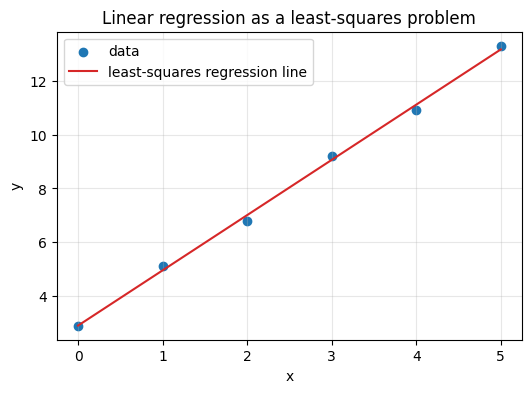

In [6]:
# Plots
plt.figure(figsize=(6, 4))
plt.scatter(x, y_data, color="tab:green", label="data")
plt.plot(x, y_pred, color="tab:red", label="least-squares regression line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression as a least-squares problem")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Here, the slope came out to about 2.08, meaning each 1-unit increase in x corresponds to roughly a 2.08 increase in y. The slope tells us the fitted change in y for each one-unit increase in x. The intercept is the fitted value when x = 0. The prediction error for thee given data is showin printed with RMSE.

## Reflection and Rubric Checklist

- Code Accuracy and Completeness: Code runs, outputs are printed without errors
- Math Concept Coverage: I calculated QR decomposition, least-squares problems, and linear regression.
- Examples Appropriateness: Examples follow guidelines and are proven in outputs
- Explanation and Documentation: Notes were given for each code boxes
- GitHub and Colab: I saved the notebook directly from Colab to GitHub, and the `Open in Colab` badge is visible and working.
- Format and Clarity: The notebook has a logical flow, readable code, and clear section headings.
- Personalization: I changed matrixes and vectors, along with explanations to show my own work.